# pH-rate Profile for Esters

**NOTE: This version of the workbook has code for more formal plots.**

In water esters have three possible routes to hydrolysis. 

1. Water attacks the carbonyl group of the ester.
2. Acid catalysis: Water attacks the protonated carbonyl group of the ester.
3. Base catalysis: Hydroxide attacks the carbonyl group of the ester

Let us explore analyzing data for ester hydrolysios

This workbook contains the code and imports the data from multiple files and fits the data to the model..

The data being plotted is from "The Hydrolysis of Diclofenac Esters: Synthetic Prodrug Building Blocks for Biodegradable Drug–Polymer Conjugates." Feng Wang, Joshua Finnin et al., *J. Pharm. Sci.*, **2016**, *105*, 773-785.  https://doi.org/10.1002/jps.24665

The data is found in tables within the supplementary material at https://ars.els-cdn.com/content/image/1-s2.0-S0022354915001550-mmc1.docx


## Setup Tools and Read Data Table

Here the data table is read in and processed. Also the libraries are imported and any functions defined

In [1]:
# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M10_Ester_Carbamate_pH-Rate_Profile/data.zip
    !unzip -q data.zip

plt.rcdefaults()

print("Setup complete")


Setup complete


## Read Data

Read the data in from the csv text file.

In [2]:
### READ DATA
# datafiles are "3ab.csv" and "3c.csv"

data_file = "data/3ab.csv"

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

print(df)

      pH  k1 (10-5 hr-1)  t1/2 (hr)     r^2
0   1.00         4270.00       16.3  0.9895
1   1.54         1010.00       68.6  0.9988
2   1.90          352.00      197.0  0.9864
3   2.80          102.00      679.0  0.9989
4   3.22           38.40     1810.0  0.9973
5   3.52           18.90     3680.0  0.9976
6   4.02            8.46     8190.0  0.9857
7   4.45            2.46    28200.0  0.8401
8   4.87            3.02    23000.0  0.8858
9   5.34           13.30     5230.0  0.9906
10  5.97           49.10     1410.0  0.9995
11  6.59          182.00      382.0  0.9998
12  6.93          412.00      168.0  0.9999
13  7.32         1050.00       66.2  0.9997
14  7.82         2880.00       24.1  0.9999


## Plot Data

This code will quickly plot the data. We idenify the columns we want to use for $x$ and $y$ and then call the plot function.

kHKa = 0.49+/-0.05
kOH = (4.7+/-0.5)e+04


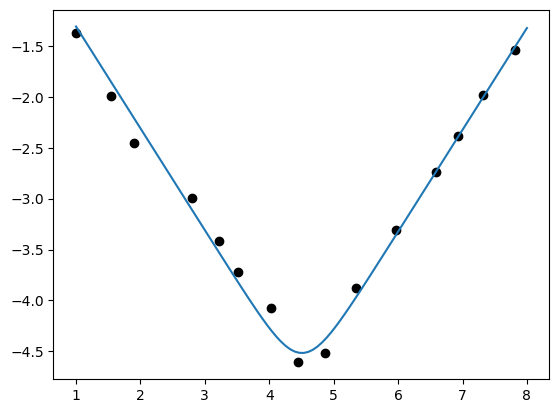

In [3]:
plt.rcdefaults()

x = df["pH"]
y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)

plt.plot(x,y, "ko")

def line1(x, int):
    ### slope set to -1. We are fitting only for the intercept.
    y = x * -1 + int
    return y

def line2(x, int):
    ### slope set to +1. We are fitting only for the intercept.
    y = x * 1 + int
    return y

def model2(pH, kHKa, kOH):
    H = 10**(-pH)
    Kw = 10**-13.995
    k1 = kHKa * H
    k2 = kOH * Kw/H
    kobs = k1 + k2
    return np.log10(kobs)
     
def model3(pH, kHKa, kH2O, kOH):
    H = 10**(-pH)
    Kw = 10**-13.995
    k1 = kHKa * H
    k2 = kOH * Kw/H
    kobs = k1 + k2 + kH2O
    return np.log10(kobs)

popt,pcov = curve_fit(model2, x, y,
                      p0 = (1,100),
                      bounds=([0,0],[np.inf,np.inf])
                      )

kHKa, kOH = un.correlated_values(popt,pcov)
print(f"kHKa = {kHKa}")
print(f"kOH = {kOH}")


x_fit = np.linspace(1,8,100)
y_fit = model2(x_fit, *popt)

plt.plot(x_fit, y_fit)


In [65]:
data_file = "data/3c.csv"

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

 ### Use curve_fit function  

# define the function for the model
def profile3(pH, kHKa, kH2O, kOH):
    H = 10**(-pH)
    Kw = 10**-13.995
    k1 = kHKa * H
    k2 = kOH * Kw/H
    kobs = k1 + k2 + kH2O
    return np.log10(kobs)

# Create a model by loading the function via the lmfit.Model tool
mod = lmfit.Model(profile3)  

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(kHKa = dict(value = 1, min=0), 
                       kH2O = dict(value = 1, min=0), 
                       kOH =  dict(value = 1, min=0),
                      )

x = df["pH"]
y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)


# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pH=x)   
#print(result.ci_report())
x

0    1.00
1    1.90
2    3.10
3    4.04
4    4.98
5    6.09
6    6.97
7    7.42
8    7.96
Name: pH, dtype: float64

In [69]:
data_file = "data/3ab.csv"

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 


### Use curve_fit function  

# define the function for the model
def profile2(pH, kHKa, kOH):
    H = 10**(-pH)
    Kw = 10**-13.995
    k1 = kHKa * H
    k2 = kOH * Kw/H
    kobs = k1 + k2
    return np.log10(kobs)

# Create a model by loading the function via the lmfit.Model tool
mod = lmfit.Model(profile2)  

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(kHKa = dict(value = 1, min=0), 
                       kOH =  dict(value = 1, min=0),
                      )

x = df["pH"]
y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)


# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pH=x)   
print(result.ci_report())


         99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 kHKa:  -0.16403  -0.10578  -0.05281   0.49009  +0.05890  +0.13341  +0.24168
 kOH :-15894.01978-10267.50592-5133.5208346783.11417+5741.47339+13026.70905+23651.14476


In [71]:
### WRONG FIT

data_file = "data/3c.csv"

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 


### Use curve_fit function  

# define the function for the model
def profile2(pH, kHKa, kOH):
    H = 10**(-pH)
    Kw = 10**-13.995
    k1 = kHKa * H
    k2 = kOH * Kw/H
    kobs = k1 + k2
    return np.log10(kobs)

# Create a model by loading the function via the lmfit.Model tool
mod = lmfit.Model(profile2)  

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(kHKa = dict(value = 1, min=0), 
                       kOH =  dict(value = 1, min=0),
                      )

x = df["pH"]
y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)


# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pH=x)   
print(result.ci_report())


         99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 kHKa:  -0.47074  -0.38550  -0.23840   0.49763  +0.45349  +1.62632  +6.47747
 kOH :-1410721.55468-1061850.77484-600429.451891626118.31512+926452.08782+2830580.20657+8865611.51229


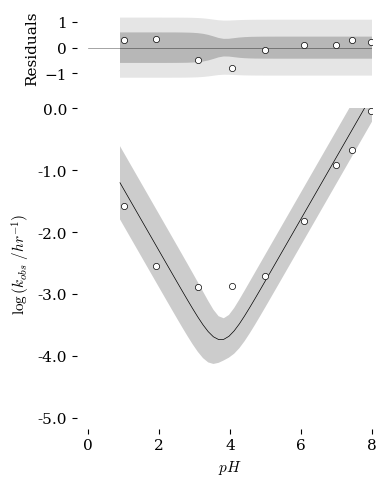

[[Model]]
    Model(profile2)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 76
    # data points      = 9
    # variables        = 2
    chi-square         = 1.22109862
    reduced chi-square = 0.17444266
    Akaike info crit   = -13.9772626
    Bayesian info crit = -13.5828134
    R-squared          = 0.86268176
[[Variables]]
    kHKa:  0.49762839 +/- 0.27935405 (56.14%) (init = 1)
    kOH:   1626118.32 +/- 659723.082 (40.57%) (init = 1)


In [75]:
###############################################################################
### FANCY PLOT OF RESULT
###############################################################################

# line fit
x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.1, 50)     # make an array of 50 points that span the data range
y_fit = result.eval(pH=x_fit)                      # the line of the line fit

# confidence interval
y_err = result.eval_uncertainty(pH=x_fit, sigma=2) # the 95% confidence interval
ci_upper = y_fit + y_err
ci_lower = y_fit - y_err

# Prediction interval

se = result.eval_uncertainty(pH=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi                             # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)            # two-tailed t-value for 95% confidence interval
pi = tval * se_pred

pi_lower = y_fit - pi
pi_upper = y_fit + pi


size2 = 4,5
###############################################################################
######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=size2, height_ratios=[1, 4])  

# Settings for plot
ax[1].set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /hr^{-1})}$",                
          xlabel=r"$pH$ ", 
          xlim=[0, 8],                  
          ylim=[-5,0]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax[1].scatter(x, y, marker = "o", s = 20, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 

# Plot the curve fit line
ax[1].plot(x_fit,unp.nominal_values(y_fit), 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 0)

# Confidence band
fit_up = y_fit + y_err
fit_dn = y_fit - y_err
ax[1].fill_between(x_fit, fit_up, fit_dn, 
                   facecolor="black", alpha=0.2, zorder = 2,
                   label="confidence interval")

ax[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f')) # 1 decimal place in y axis

ax[1].spines["left"].set_position(("outward", 8))
ax[1].spines["bottom"].set_position(("outward", 8))


######################
### Plot the residuals
######################

# difference between data and line-fit
residuals = -result.residual     

ax[0].set(
#          title = Title,       
          ylabel=r"Residuals", 
          xlabel=r"",                
#          xlim=[0, np.max(x) + np.max(x) * 0.1],                  
          xlim=[0, 8],                  
#          ylim=[-np.max(residuals)*3,np.max(residuals)*3]
          ylim=[-1.5,1.5]
       )
### Data graphics
ax[0].scatter(x, residuals, marker = "o", s = 20, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 3)
# make filled band
ax[0].fill_between(x_fit, y_err, -y_err, 
                   facecolor="black", alpha=0.2, zorder = 1,
                   linewidth = 0, label="confidence interval")
ax[0].fill_between(x_fit, pi, -pi, 
                   facecolor="black", alpha=0.1, zorder = 1,
                   linewidth = 0, label="confidence interval")

### Other elements
ax[0].axhline(0, color='gray', linewidth=0.5, zorder = 0) 

#ax[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f')) # 1 decimal place in y axis

ax[0].spines["left"].set_position(("outward", 8))
#ax[0].spines["bottom"].set_position(("outward", 8))

ax[0].set_xticks([])

################################################
### Output Plot
################################################

name = "presD2"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax[0].patch.set_facecolor([0, 0, 0, 0])  
ax[1].patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()
print(result.fit_report())


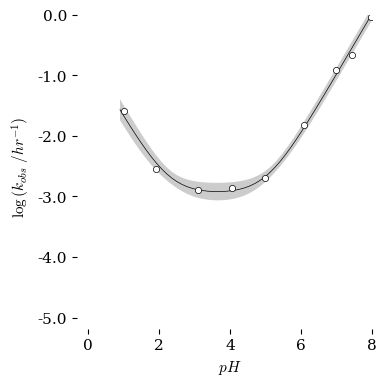

[[Model]]
    Model(profile3)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 38
    # data points      = 9
    # variables        = 3
    chi-square         = 0.04226078
    reduced chi-square = 0.00704346
    Akaike info crit   = -42.2500836
    Bayesian info crit = -41.6584099
    R-squared          = 0.99524758
[[Variables]]
    kHKa:  0.20442919 +/- 0.03429308 (16.78%) (init = 1)
    kH2O:  0.00110699 +/- 1.6074e-04 (14.52%) (init = 1)
    kOH:   1024894.12 +/- 99733.5348 (9.73%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(kHKa, kH2O) = -0.2353
    C(kH2O, kOH)  = -0.1581


In [66]:
###############################################################################
### FANCY PLOT OF RESULT
###############################################################################

# line fit
x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.1, 50)     # make an array of 50 points that span the data range
y_fit = result.eval(pH=x_fit)                      # the line of the line fit

# confidence interval
y_err = result.eval_uncertainty(pH=x_fit, sigma=2) # the 95% confidence interval
ci_upper = y_fit + y_err
ci_lower = y_fit - y_err

# Prediction interval

se = result.eval_uncertainty(pH=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi                             # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)            # two-tailed t-value for 95% confidence interval
pi = tval * se_pred

pi_lower = y_fit - pi
pi_upper = y_fit + pi


size2 = 4,4
###############################################################################
######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=size2,)  

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /hr^{-1})}$",                
          xlabel=r"$pH$ ", 
          xlim=[0, 8],                  
          ylim=[-5,0]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
if 1:
    ax.scatter(x, y, marker = "o", s = 20, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 

# Plot the curve fit line
if 1:
    ax.plot(x_fit,unp.nominal_values(y_fit), 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 2)

if 0:
    kHKa = result.uvars['kHKa'].n
    kOH = result.uvars['kOH'].n

    KW = 10**(-14)
    k_obs_EH = kHKa * 10**(-x_fit)  
    #k_obs_E = k_E + 0*x  # The 0*x will produce data points to match x
    k_obs_OH = kOH * KW/10**(-x_fit)
    #k_obs_OAc = k_OAc * Ka_HOAc / (a_H + Ka_HOAc) * c_AcOH

    ax.plot(x_fit,np.log10(k_obs_EH), 
           marker = None, color = "red", 
           linewidth=0.5, zorder = 1)
    ax.plot(x_fit,np.log10(k_obs_OH), 
           marker = None, color = "red", 
           linewidth=0.5, zorder = 1)
if 0:
    kHKa = result.uvars['kHKa'].n
    kOH = result.uvars['kOH'].n
    kH2O = result.uvars['kH2O'].n

    KW = 10**(-14)
    k_obs_EH = kHKa * 10**(-x_fit)  
    k_obs_H2O = kH2O + 0*10**(-x_fit)  # The 0*x will produce data points to match x
    k_obs_OH = kOH * KW/10**(-x_fit)
    #k_obs_OAc = k_OAc * Ka_HOAc / (a_H + Ka_HOAc) * c_AcOH

    ax.plot(x_fit,np.log10(k_obs_EH), 
           marker = None, color = "red", 
           linewidth=0.5, zorder = 1)
    ax.plot(x_fit,np.log10(k_obs_OH), 
           marker = None, color = "red", 
           linewidth=0.5, zorder = 1)
    ax.plot(x_fit,np.log10(k_obs_H2O), 
           marker = None, color = "red", 
           linewidth=0.5, zorder = 1)



# Confidence band
fit_up = y_fit + y_err
fit_dn = y_fit - y_err
if 1:
    ax.fill_between(x_fit, fit_up, fit_dn, 
                   facecolor="black", alpha=0.2, zorder = 0,
                   label="confidence interval")

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f')) # 1 decimal place in y axis

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))



################################################
### Output Plot
################################################

name = "presC4x"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()
print(result.fit_report())
